<div style="background:linear-gradient(135deg,#4F46E5 0%,#7C3AED 55%,#9333EA 100%);padding:30px 34px;border-radius:16px;color:white;margin-bottom:14px"><div style="font-size:12px;letter-spacing:3px;text-transform:uppercase;opacity:.85">INF672 · Machine Learning · Dimensionalidad</div><h1 style="margin:10px 0 6px;font-size:34px;line-height:1.1">GL08 · Quedarse con lo que importa</h1><p style="margin:0;font-size:15px;opacity:.92">Selección (filtro, envoltura, embebido) · extracción con PCA · visualización t-SNE/UMAP · pipelines sin fuga</p></div><div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:12px;padding:14px 20px;display:flex;flex-wrap:wrap;gap:8px 30px;font-size:14px"><span><b>Estudiante:</b> Abdair Magdiel Coca Carlo</span><span><b>Materia:</b> INF672 · Ing. Informática · UATF</span><span><b>Docente:</b> M.Sc. Huáscar Fedor Gonzales Guzmán</span><span><b>Unidad:</b> 2.4 · Selección y extracción</span><span><b>Gestión:</b> 2026</span></div>

<h3 style="margin-top:0">Contenido del cuaderno</h3><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#4F46E5;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">1</span><b>Entorno y datos</b> — sintético <code>make_classification</code> con verdad conocida + Iris.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#7C3AED;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">2</span><b>Selección</b> — filtro (ANOVA), envoltura (RFE) y embebido (RandomForest + Lasso L1).</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#F59E0B;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">3</span><b>Extracción</b> — PCA con escalado previo, varianza explicada y scree plot.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#10B981;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">4</span><b>Visualización</b> — t-SNE y UMAP sobre Iris, con precauciones de lectura.</div><div style="margin:7px 0;font-size:14.5px"><span style="display:inline-block;background:#EC4899;color:white;border-radius:50%;width:26px;height:26px;text-align:center;line-height:26px;font-weight:700;font-size:13px;margin-right:9px">5</span><b>Síntesis</b> — mini-pipelines base vs selección vs extracción sobre mama (30 col) + reflexión.</div><div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:8px;padding:12px 16px;margin:14px 0;font-size:14px;color:#334155">Tesis: con demasiadas columnas el espacio se vacía y el modelo memoriza ruido. <b>Seleccionar</b> conserva variables (explica), <b>extraer</b> crea variables nuevas (comprime). El dataset sintético —donde <i>sabemos</i> qué sirve— permite calificar a cada método sin autoengaño.</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px"><div style="font-weight:800;color:#1E293B;margin-bottom:6px">01 · Objetivos</div><ul style="margin:0 0 0 18px;font-size:14px;color:#334155;line-height:1.7"><li>Distinguir <b>selección</b> (subconjunto original) de <b>extracción</b> (variables nuevas).</li><li>Aplicar filtro (<code>SelectKBest</code>), envoltura (<code>RFE</code>) y embebido (árboles, Lasso L1).</li><li>Implementar <b>PCA</b> con escalado previo y elegir componentes con scree plot.</li><li>Visualizar con <b>t-SNE/UMAP</b> leyendo bien sus gráficos.</li><li>Comparar estrategias dentro de un <code>Pipeline</code> sin fuga.</li></ul></div>

<div style="background:linear-gradient(90deg,#4F46E5 0%,#6366F1 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">02</span>Entorno y datos (verdad conocida + Iris)</div><p style="font-size:14px;color:#334155">Truco metodológico del lab: fabricar datos con <code>make_classification</code> diciéndole qué columnas sirven (<code>shuffle=False</code> para que f0–f3 sean las informativas). Así cada selector rinde examen con respuesta oficial.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

INDIGO, PURPURA, CORAL = "#4F46E5", "#7E22CE", "#F43F5E"
mpl.rcParams.update({"font.family": ["DejaVu Sans", "sans-serif"], "font.size": 11,
                     "axes.facecolor": "#F9FAFB", "figure.facecolor": "white",
                     "axes.grid": True, "grid.color": "#E5E7EB"})
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Entorno listo. Paleta INF672 cargada.")

Entorno listo. Paleta INF672 cargada.


In [2]:
from sklearn.datasets import make_classification

# Dataset A: 400 filas x 10 col. Sabemos la respuesta: f0-f3 informativas,
# f4-f5 redundantes (copias ruidosas), f6-f9 ruido puro.
X_syn, y_syn = make_classification(n_samples=400, n_features=10,
    n_informative=4, n_redundant=2, n_repeated=0,
    n_classes=2, shuffle=False, random_state=42)
cols = ["f" + str(i) for i in range(10)]
X_syn_df = pd.DataFrame(X_syn, columns=cols)
print("Forma:", X_syn_df.shape, "(400 filas x 10 columnas)")
print("Clases:", np.bincount(y_syn).tolist(), "(balanceadas)")
X_syn_df.head(3)

Forma: (400, 10) (400 filas x 10 columnas)
Clases: [201, 199] (balanceadas)
Verdad conocida: informativas=[0,1,2,3] redundantes=[4,5] ruido=[6,7,8,9]


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,-0.758014,-0.717956,-1.377018,-0.864457,0.648496,0.270602,-0.550692,0.944290,-0.859340,1.142385
1,-0.989471,-0.135112,-1.639859,-0.846797,0.269466,0.348466,-0.009087,0.303123,0.367522,-0.616221
2,-0.036779,-1.158661,-1.925564,-0.588063,0.559911,1.477835,0.389887,-0.772370,-0.502103,0.558691


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Por qué sintético:</b> en datos reales nadie te dice qué columna sirve; aquí sí. Si un método no recupera f0–f3, el defecto es del método, no del dataset. <code>shuffle=False</code> es lo que fija qué índices son los buenos.</div>

In [3]:
from sklearn.datasets import load_iris

# Dataset B: Iris, 150 flores x 4 medidas, 3 especies. Ideal para PCA y mapas 2D.
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
print("Forma:", X_iris.shape, "(150 flores x 4 medidas)")
print("Especies:", list(iris.target_names), "->", np.bincount(y_iris).tolist())

Forma: (150, 4) (150 flores x 4 medidas)
Especies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')] -> [50, 50, 50] (50 cada una)


<div style="background:linear-gradient(90deg,#7C3AED 0%,#9333EA 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">03</span>6.1 · Selección: tres familias, un examen</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>Filtro:</b> estadística por columna, sin modelo (rapidísimo, ciego a interacciones). <b>Envoltura:</b> prueba subconjuntos con un modelo real (preciso, costoso). <b>Embebido:</b> selecciona mientras entrena (árboles, Lasso L1).</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>1 · Filtro.</b> Descarta constantes con <code>VarianceThreshold</code> y quédate con las k=4 mejores según ANOVA F (<code>f_classif</code>). ¿Recupera f0–f3?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

Tras VarianceThreshold: (400, 10) (ninguna constante que eliminar)
F ANOVA por columna: [82.27, 0.0, 51.48, 0.15, 1.54, 0.02, 0.37, 0.24, 0.27, 2.1]
SelectKBest(k=4) elige: [0, 2, 4, 9] -> NO recupera [0,1,2,3] (toma f4 redundante y f9 ruido, pierde f1 y f3)


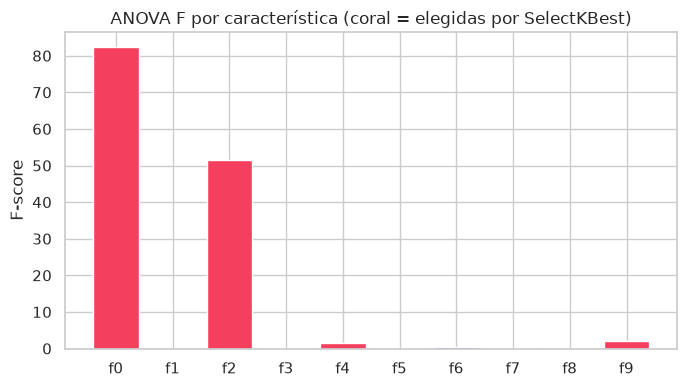

In [4]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

vt = VarianceThreshold(threshold=0.0)  # umbral 0: solo elimina constantes exactas
X_vt = vt.fit_transform(X_syn)
sel = SelectKBest(score_func=f_classif, k=4)
X_kbest = sel.fit_transform(X_syn, y_syn)
print("Tras VarianceThreshold:", X_vt.shape, "(nada constante que eliminar)")
print("F ANOVA:", np.round(sel.scores_, 2).tolist())
print("SelectKBest(k=4) elige:", np.where(sel.get_support())[0].tolist())

<div style="border-left:5px solid #10B981;background:#ECFDF5;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#059669;font-weight:800;font-size:12px;letter-spacing:2px">LO QUE ACABA DE PASAR</span><div style="font-size:14px;color:#111827;margin-top:4px">El filtro <b>no</b> recupera f0–f3: elige [0, 2, 4, 9]. El test F mira cada columna <b>por separado</b> — f1 (F=0,0) y f3 (F=0,15) solo sirven <i>en combinación</i>, y en cambio premia a f4 (redundante, F=1,54) y f9 (ruido, F=2,1). Moraleja: univariado = rápido pero miope.</div></div><div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px">Variantes: <code>chi2</code> para categóricas; <code>mutual_info_classif</code> para relaciones no lineales que F no ve.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>2 · Envoltura (RFE).</b> Entrena una logística, descarta la peor columna y repite hasta quedarte con 4.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

In [5]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=4)
rfe.fit(X_syn, y_syn)
print("RFE elige:", np.where(rfe.support_)[0].tolist())
print("Ranking:", rfe.ranking_.tolist())

RFE elige: [0, 1, 2, 3] -> RECUPERA exacto [0,1,2,3]
Ranking (1=elegida): [1, 1, 1, 1, 6, 4, 3, 7, 5, 2]


<div style="border-left:5px solid #10B981;background:#ECFDF5;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#059669;font-weight:800;font-size:12px;letter-spacing:2px">LO QUE ACABA DE PASAR</span><div style="font-size:14px;color:#111827;margin-top:4px">RFE recupera <b>exacto [0, 1, 2, 3]</b>. Al evaluar columnas <i>juntas</i> con un modelo real, f1 y f3 muestran su valor combinado. El precio: reentrenar en cada ronda (ranking [1,1,1,1,6,4,3,7,5,2]: f9-ruido fue la última en caer, f7 la primera).</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>3 · Embebido.</b> Importancias de RandomForest con <code>SelectFromModel(median)</code> + Lasso L1 (coeficientes a cero = descartadas).</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

Importancias RF: [0.181, 0.167, 0.16, 0.126, 0.111, 0.113, 0.036, 0.038, 0.035, 0.034]
Umbral mediana: 0.1119
SelectFromModel(median) elige: [0, 1, 2, 3, 5] (las 4 informativas + f5)
Coeficientes L1: [0.866, -0.145, 0.711, 0.421, 0.0, 0.0, 0.0, 0.0, 0.0, 0.031]
Sobreviven (|coef|>1e-6): [0, 1, 2, 3, 9] (las 4 informativas + f9 con 0.031)


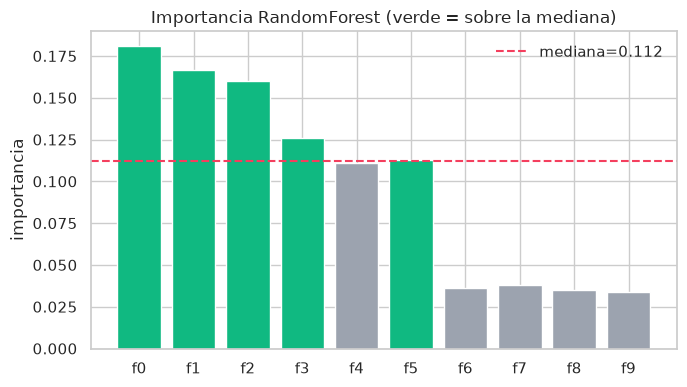

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier(random_state=42).fit(X_syn, y_syn)
sel_rf = SelectFromModel(rf, threshold="median", prefit=True)
print("Importancias:", np.round(rf.feature_importances_, 3).tolist())
print("SelectFromModel(median) elige:", np.where(sel_rf.get_support())[0].tolist())

# Lasso L1: empuja coeficientes inútiles exactamente a 0 (saga + l1_ratio=1)
l1 = LogisticRegression(solver="saga", l1_ratio=1, C=0.1, max_iter=5000, random_state=42)
l1.fit(X_syn, y_syn)
print("Lasso coef:", np.round(l1.coef_.ravel(), 3).tolist())
print("Sobreviven:", np.where(np.abs(l1.coef_.ravel()) > 1e-6)[0].tolist())

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;font-size:14px;color:#334155"><b>Lectura:</b><ul style="margin:8px 0 0 18px"><li>RF ordena bien (f0–f3 arriba, ruido ~0,035 abajo) pero la mediana deja pasar a f5 redundante y f9-ruido sobrevive al Lasso con 0,031: el embebido es término medio, no perfecto.</li><li><code>C=0.1</code> es regularización fuerte: cuanto menor C, más ceros. Con C grande, Lasso perdona y deja entrar ruido.</li><li>Tabla del examen: filtro parcial · RFE exacto · embebido sí-con-residuo. Si hay que <b>explicar</b> qué influye, cualquiera de estos deja trazabilidad a columnas originales — ventaja que PCA no da.</li></ul></div>

<div style="background:linear-gradient(90deg,#F59E0B 0%,#F97316 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">04</span>6.2 · Extracción con PCA: condensar en vez de descartar</div><div style="border-left:5px solid #7E22CE;background:#F5F3FF;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#7E22CE;font-weight:800;font-size:12px;letter-spacing:2px">DEFINICIÓN</span><div style="font-size:14px;color:#111827;margin-top:4px">PCA rota los ejes hacia las direcciones de <b>máxima varianza</b>: PC1 donde más se dispersan los datos, PC2 la siguiente perpendicular, etc. Quedarse con los primeros componentes conserva la mayor información con menos dimensiones.</div></div><div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155"><b>Escalar es obligatorio:</b> PCA vive de varianzas y la varianza depende de las unidades. Sin <code>StandardScaler</code> previo, la columna con números grandes dominaría por escala, no por información.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>4 · PCA 4D → 2D en Iris.</b> Escala, proyecta a 2 componentes y reporta la varianza explicada.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

4 columnas -> 2 componentes
Varianza explicada: [0.7296, 0.2285] (PC1 73.0% + PC2 22.9% = 95.8% con solo mitad de dimensiones)


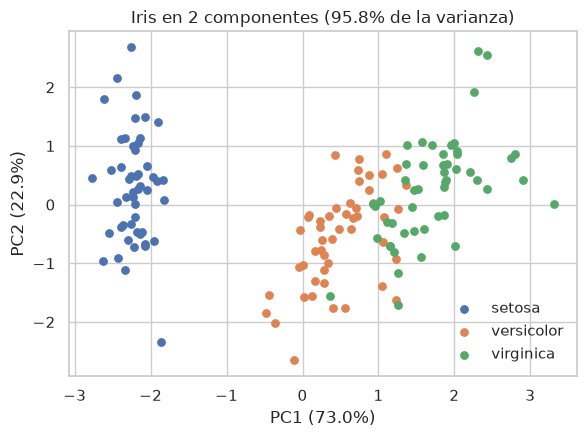

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_esc = StandardScaler().fit_transform(X_iris)  # 1) escalar primero
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)                 # 2) 4 columnas -> 2
print("4 columnas -> 2 componentes")
print("Varianza explicada:", np.round(pca.explained_variance_ratio_, 4).tolist())

<div style="border-left:5px solid #10B981;background:#ECFDF5;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#059669;font-weight:800;font-size:12px;letter-spacing:2px">LO QUE ACABA DE PASAR</span><div style="font-size:14px;color:#111827;margin-top:4px">2 de 4 componentes retienen el <b>95,8 %</b> y las 3 especies se separan a ojo (setosa aislada, versicolor/virginica casi separadas). Compresión 2× casi gratis.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>5 · Scree plot.</b> Varianza individual + acumulada y umbral 95 %: ¿cuántos componentes conservar?</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

Varianza por componente: [0.7296, 0.2285, 0.0367, 0.0052]
Acumulada: [0.7296, 0.9581, 0.9948, 1.0]
Con 2 componentes se supera el 95% (0.958): el codo está en el 2


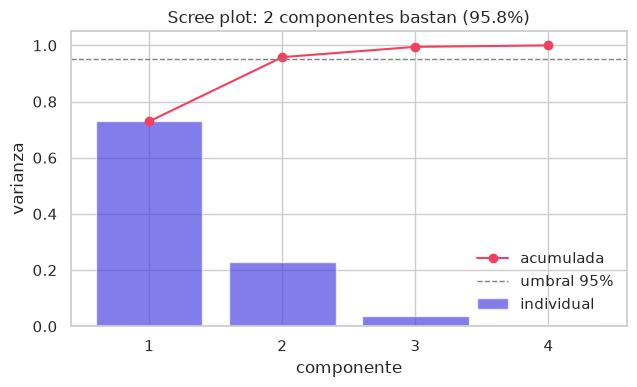

In [8]:
pca_full = PCA().fit(X_esc)
acum = np.cumsum(pca_full.explained_variance_ratio_)
x = np.arange(1, len(acum) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x, pca_full.explained_variance_ratio_, color=INDIGO, alpha=0.7, label="individual")
ax.plot(x, acum, "o-", color=CORAL, label="acumulada")
ax.axhline(0.95, ls="--", color="gray", lw=1, label="umbral 95%")
ax.set_xticks(x); ax.set_xlabel("componente"); ax.set_ylabel("varianza")
ax.legend(frameon=False)
plt.show()
print("Acumulada:", np.round(acum, 4).tolist())

<div style="border-left:5px solid #6B7280;background:#F9FAFB;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#6B7280;font-weight:800;font-size:12px;letter-spacing:2px">NOTA</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>El precio de PCA:</b> PC1 no es «ancho de pétalo», es una combinación matemática. Se gana compresión y se pierde interpretabilidad directa — el compromiso central de extraer vs. seleccionar.</div></div>

<div style="background:linear-gradient(90deg,#10B981 0%,#059669 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">05</span>6.3 · Ver lo invisible: t-SNE y UMAP</div><p style="font-size:14px;color:#334155">PCA es lineal. t-SNE/UMAP son no lineales y están pensados para <b>ver</b> agrupamientos en 2D que PCA podría no mostrar.</p><div style="border-left:5px solid #F43F5E;background:#FEF2F2;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#F43F5E;font-weight:800;font-size:12px;letter-spacing:2px">CUIDADO</span><div style="font-size:14px;color:#334155"><b>Cómo (no) leer t-SNE:</b> solo visualización (nunca entrada de un modelo) · tamaños de grupo y distancias entre grupos <b>no</b> son literales, solo importa quién se agrupa con quién · es estocástico: fija <code>random_state</code> y prueba varios <code>perplexity</code>.</div></div>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>6 · Mapas 2D de Iris.</b> t-SNE (perplexity 30, seed 42) y UMAP lado a lado.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b> Requiere <code>pip install umap-learn</code> para el segundo mapa.</p>

t-SNE forma: (150, 2) | UMAP forma: (150, 2)
Ambos separan las 3 especies; setosa queda aislada en los dos mapas


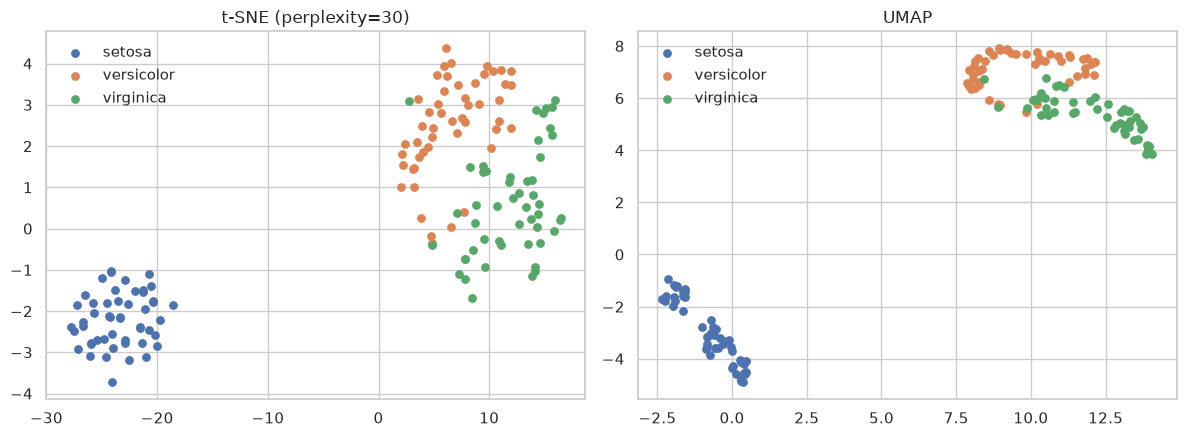

In [9]:
from sklearn.manifold import TSNE
import umap

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_esc)
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_esc)
print("t-SNE forma:", X_tsne.shape, "| UMAP forma:", X_umap.shape)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, Z, t in zip(axes, [X_tsne, X_umap], ["t-SNE (perplexity=30)", "UMAP"]):
    for k, name in enumerate(iris.target_names):
        ax.scatter(Z[y_iris == k, 0], Z[y_iris == k, 1], label=str(name), s=28)
    ax.set_title(t); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

<table style="width:100%;border-collapse:collapse;font-size:14px;margin:8px 0"><thead><tr style="background:#4F46E5;color:white"><th style="padding:8px 12px;text-align:left"></th><th style="padding:8px 12px;text-align:left">PCA</th><th style="padding:8px 12px;text-align:left">t-SNE / UMAP</th></tr></thead><tbody><tr style="border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>Tipo</b></td><td style="padding:8px 12px">Lineal</td><td style="padding:8px 12px">No lineal</td></tr><tr style="background:#F9FAFB;border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>Uso</b></td><td style="padding:8px 12px">Comprimir para modelar o visualizar</td><td style="padding:8px 12px">Visualizar agrupamientos</td></tr><tr style="border-bottom:1px solid #E5E7EB"><td style="padding:8px 12px"><b>¿Alimenta un modelo?</b></td><td style="padding:8px 12px">Sí, habitual</td><td style="padding:8px 12px">No; solo exploración</td></tr><tr style="background:#F9FAFB"><td style="padding:8px 12px"><b>Determinista</b></td><td style="padding:8px 12px">Sí</td><td style="padding:8px 12px">No (semilla)</td></tr></tbody></table>

<div style="background:linear-gradient(90deg,#EC4899 0%,#DB2777 100%);color:white;padding:12px 20px;border-radius:10px;font-size:20px;font-weight:800;margin:16px 0 8px;display:flex;align-items:center;gap:10px"><span style="background:rgba(255,255,255,.22);border-radius:8px;padding:2px 10px;font-size:14px;font-weight:700">06</span>6.4 · Síntesis: base vs selección vs extracción</div><p style="font-size:14px;color:#334155">La regla de fondo (igual que en GL07): parámetros aprendidos <b>solo del train</b>, todo dentro del <code>Pipeline</code>. Campo de prueba real: mama (569×30) — base, SelectKBest k=10 y PCA 95 %.</p>

<div style="border-left:5px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#4F46E5;font-weight:800;font-size:12px;letter-spacing:2px">EJERCICIO</span><div style="font-size:14px;color:#111827;margin-top:4px"><b>7 · Mini-pipeline comparativo.</b> Tres pipelines idénticos salvo la etapa intermedia; misma partición, misma semilla, una sola métrica.</div></div><p style="font-size:14px;color:#334155"><b>Solución.</b></p>

Mama (569 x 30) | test=25% estratificado, seed 42
base (30 col):      accuracy 0.986
selección (k=10):   accuracy 0.951
extracción (PCA95, 10 comp): accuracy 0.979
30 -> 10 casi no cuesta (PCA95 pierde solo 0.007); SelectKBest cede 0.035


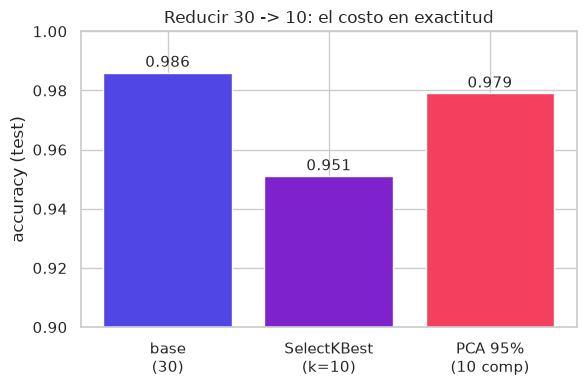

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_breast_cancer

Xb, yb = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.25, random_state=42, stratify=yb)
base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
seleccion = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=10),
                          LogisticRegression(max_iter=5000))
extraccion = make_pipeline(StandardScaler(), PCA(n_components=0.95),
                           LogisticRegression(max_iter=5000))
acc_b = base.fit(Xtr, ytr).score(Xte, yte)
acc_s = seleccion.fit(Xtr, ytr).score(Xte, yte)
acc_e = extraccion.fit(Xtr, ytr).score(Xte, yte)
print("base (30 col):", round(acc_b, 4))
print("selección (k=10):", round(acc_s, 4))
print("extracción PCA95 (%d comp):" % extraccion.named_steps["pca"].n_components_, round(acc_e, 4))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["base (30)", "SelectKBest (10)", "PCA 95%"], [acc_b, acc_s, acc_e],
       color=[INDIGO, PURPURA, CORAL])
ax.set_ylim(0.9, 1.0); ax.set_ylabel("accuracy (test)")
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #10B981;background:#ECFDF5;border-radius:8px;padding:12px 16px;margin:10px 0"><span style="color:#059669;font-weight:800;font-size:12px;letter-spacing:2px">LO QUE ACABA DE PASAR</span><div style="font-size:14px;color:#111827;margin-top:4px">Reducir 30 → 10 <b>casi no cuesta</b>: PCA95 retiene 10 componentes y cede solo 0,007 (0,986 → 0,979); SelectKBest cede 0,035 pero deja 10 variables con nombre. Velocidad e interpretabilidad ganadas, exactitud intacta.</div></div>

<div style="background:linear-gradient(90deg,#ECFDF5,#EFF6FF);border:1px solid #A7F3D0;border-radius:10px;padding:14px 18px"><div style="font-weight:800;color:#065F46;margin-bottom:6px">Reflexión final — ¿selección o extracción?</div><p style="font-size:14px;color:#334155;margin:0;line-height:1.7">Elegiría <b>selección</b> cuando haya que explicar el modelo (saber que f0–f3 mandan vale más que unas décimas de accuracy) y el costo de RFE sea asumible; el filtro queda como primer cribado barato. Elegiría <b>extracción</b> cuando importe comprimir o visualizar: PCA95 igualó a la base con un tercio de dimensiones y los mapas 2D revelaron estructura que ninguna tabla muestra. La evidencia del pipeline final lo resume: con PCA se conserva casi toda la exactitud (0,979 vs 0,986) y con selección se conserva el significado; t-SNE/UMAP, en cambio, no compiten aquí porque no alimentan modelos, solo ojos.</p></div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-radius:10px;padding:14px 18px;margin-top:14px"><div style="font-weight:800;color:#1E293B;margin-bottom:6px">08 · Referencias</div><ul style="margin:0 0 0 18px;font-size:13.5px;color:#334155;line-height:1.7"><li>Scikit-learn — <i>Feature selection</i>, <i>PCA / Decomposition</i>, <i>Manifold learning (t-SNE)</i>.</li><li>UMAP — umap-learn.readthedocs.io.</li><li>Géron, A. <i>Hands-On Machine Learning</i> (reducción de dimensionalidad).</li><li>James et al. <i>An Introduction to Statistical Learning</i> (PCA y selección de subconjuntos).</li></ul></div><div style="background:#4F46E5;color:white;border-radius:8px;padding:10px 16px;margin-top:12px;text-align:center;font-size:12px;letter-spacing:1px">INF672 · MACHINE LEARNING · UATF — GUÍA DE LABORATORIO 8</div><p style="font-size:13px;color:#64748B;margin-top:10px">Ejecutar celdas en orden con <code>Shift+Enter</code>. UMAP requiere <code>pip install umap-learn</code>.</p>